In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# Load features
df = pd.read_parquet("../data/processed/features.parquet")

# Drop rows without labels
df = df.dropna(subset=["future_vol"])

print(f"Shape: {df.shape}")
print(f"Time range: {df['timestamp'].iloc[0]} to {df['timestamp'].iloc[-1]}")
df.head()

Shape: (38692, 14)
Time range: 2026-04-02T00:24:12.51050852Z to 2026-04-03T02:28:55.776464181Z


,timestamp,received_at,midprice,spread,spread_pct,book_imbalance,return_mean,return_std,return_skew,tick_count,price_range,price_range_pct,volume_24h,future_vol
0,2026-04-02T00:24:12.51050852Z,2026-04-02T00:24:12.515394+00:00,68201.285,0.01,1.466248e-07,0.650694,0.0,0.0,0.0,10,0.0,0.0,9755.22447,0.000019
1,2026-04-02T00:24:12.763422407Z,2026-04-02T00:24:12.766983+00:00,68201.285,0.01,1.466248e-07,0.654786,0.0,0.0,0.0,11,0.0,0.0,9755.22447,0.000019
2,2026-04-02T00:24:13.011373193Z,2026-04-02T00:24:13.014975+00:00,68201.285,0.01,1.466248e-07,0.659880,0.0,0.0,0.0,12,0.0,0.0,9755.22447,0.000019
3,2026-04-02T00:24:13.262203766Z,2026-04-02T00:24:13.265610+00:00,68201.285,0.01,1.466248e-07,0.667656,0.0,0.0,0.0,13,0.0,0.0,9755.22447,0.000019
4,2026-04-02T00:24:13.512344859Z,2026-04-02T00:24:13.517570+00:00,68201.285,0.01,1.466248e-07,0.854309,0.0,0.0,0.0,14,0.0,0.0,9755.22447,0.000020


In [24]:
df.describe().round(6)

,midprice,spread,spread_pct,book_imbalance,return_mean,return_std,return_skew,tick_count,price_range,price_range_pct,volume_24h,future_vol
count,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000,38692.000000
mean,66946.094248,0.119463,0.000002,-0.057382,-0.000000,0.000023,-0.499465,285.041998,44.626849,0.000667,8488.295434,0.000022
std,592.040213,0.441425,0.000007,0.823798,0.000002,0.000010,3.614236,48.904467,28.337681,0.000424,717.381227,0.000010
min,66404.335000,0.010000,0.000000,-1.000000,-0.000015,0.000000,-10.449132,10.000000,0.000000,0.000000,7643.861957,0.000000
25%,66577.485000,0.010000,0.000000,-0.942263,-0.000001,0.000016,-3.053525,261.000000,26.565000,0.000397,7844.264258,0.000016
50%,66747.915000,0.010000,0.000000,-0.168852,-0.000000,0.000021,-0.564353,285.000000,37.930000,0.000566,8545.984888,0.000021
75%,66930.335000,0.010000,0.000000,0.863835,0.000001,0.000028,1.814604,313.000000,53.570000,0.000801,9049.948461,0.000027
max,68500.475000,13.520000,0.000202,1.000000,0.000008,0.000061,11.938176,418.000000,175.930000,0.002637,9820.222190,0.000061


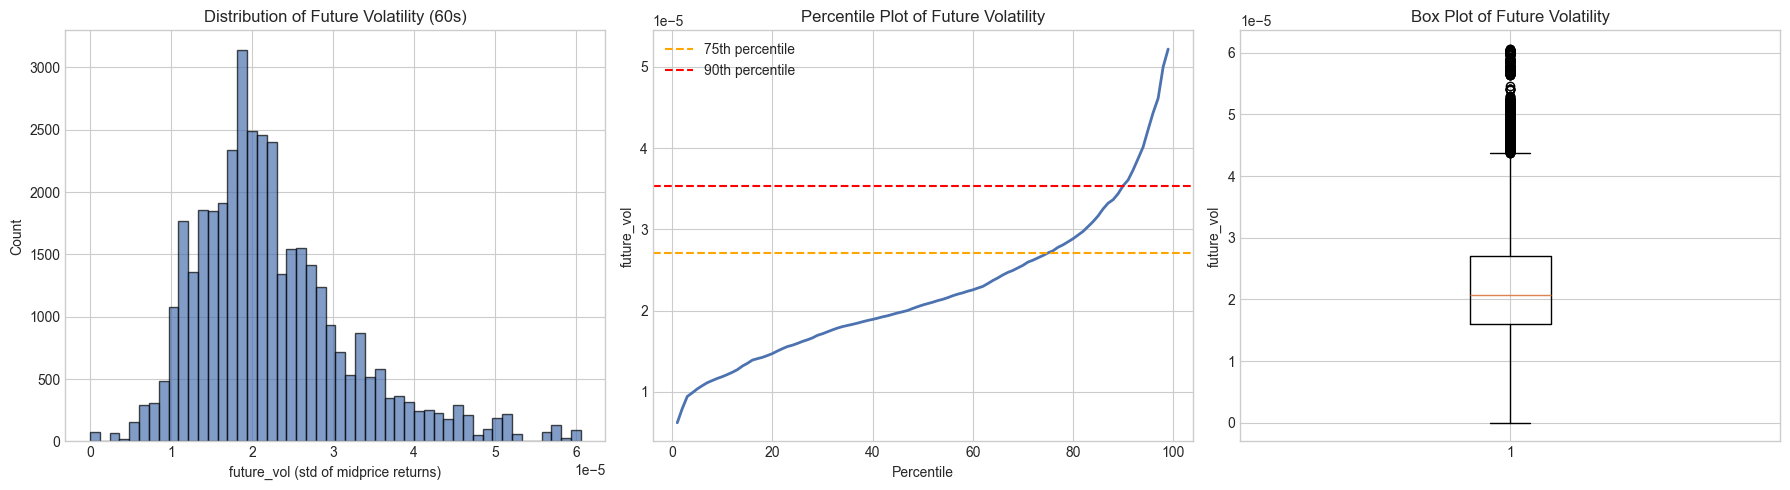

Key percentiles of future_vol:
  50th percentile: 0.00002069
  75th percentile: 0.00002709
  80th percentile: 0.00002884
  85th percentile: 0.00003164
  90th percentile: 0.00003535
  95th percentile: 0.00004227


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Histogram of future_vol
axes[0].hist(df["future_vol"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of Future Volatility (60s)")
axes[0].set_xlabel("future_vol (std of midprice returns)")
axes[0].set_ylabel("Count")

# Plot 2: Percentile plot (this is what the assignment asks for)
percentiles = np.arange(1, 100)
values = np.percentile(df["future_vol"], percentiles)
axes[1].plot(percentiles, values, linewidth=2)
axes[1].set_title("Percentile Plot of Future Volatility")
axes[1].set_xlabel("Percentile")
axes[1].set_ylabel("future_vol")
axes[1].axhline(y=np.percentile(df["future_vol"], 75), color="orange", 
                linestyle="--", label="75th percentile")
axes[1].axhline(y=np.percentile(df["future_vol"], 90), color="red", 
                linestyle="--", label="90th percentile")
axes[1].legend()

# Plot 3: Box plot
axes[2].boxplot(df["future_vol"], vert=True)
axes[2].set_title("Box Plot of Future Volatility")
axes[2].set_ylabel("future_vol")

plt.tight_layout()
plt.savefig("../reports/eda_future_vol.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key percentiles
print("Key percentiles of future_vol:")
for p in [50, 75, 80, 85, 90, 95]:
    val = np.percentile(df["future_vol"], p)
    print(f"  {p}th percentile: {val:.8f}")

In [26]:
# ── Cell 3b: Create spike label ──────────────────────────────────
# WHY: Our prediction task is binary classification — "will volatility
# spike in the next 60 seconds?" We need to convert the continuous
# future_vol into a 0/1 label using our chosen threshold τ.
#
# We picked the 85th percentile (τ = 0.00003321) so that ~15% of
# windows are labeled as spikes. This gives us enough positive
# examples for training (~1,470) while still representing genuinely
# elevated volatility, not just noise.

TAU = 0.00003321  # 85th percentile of future_vol

df["spike"] = (df["future_vol"] >= TAU).astype(int)

spike_counts = df["spike"].value_counts()
spike_pct = df["spike"].mean() * 100

print(f"Threshold τ = {TAU}")
print(f"\nSpike distribution:")
print(f"  No spike (0): {spike_counts[0]:,}")
print(f"  Spike    (1): {spike_counts[1]:,}")
print(f"\nSpike prevalence: {spike_pct:.1f}%")
print(f"Class ratio (neg:pos): {spike_counts[0] / spike_counts[1]:.1f}:1")

Threshold τ = 3.321e-05

Spike distribution:
  No spike (0): 33,664
  Spike    (1): 5,028

Spike prevalence: 13.0%
Class ratio (neg:pos): 6.7:1


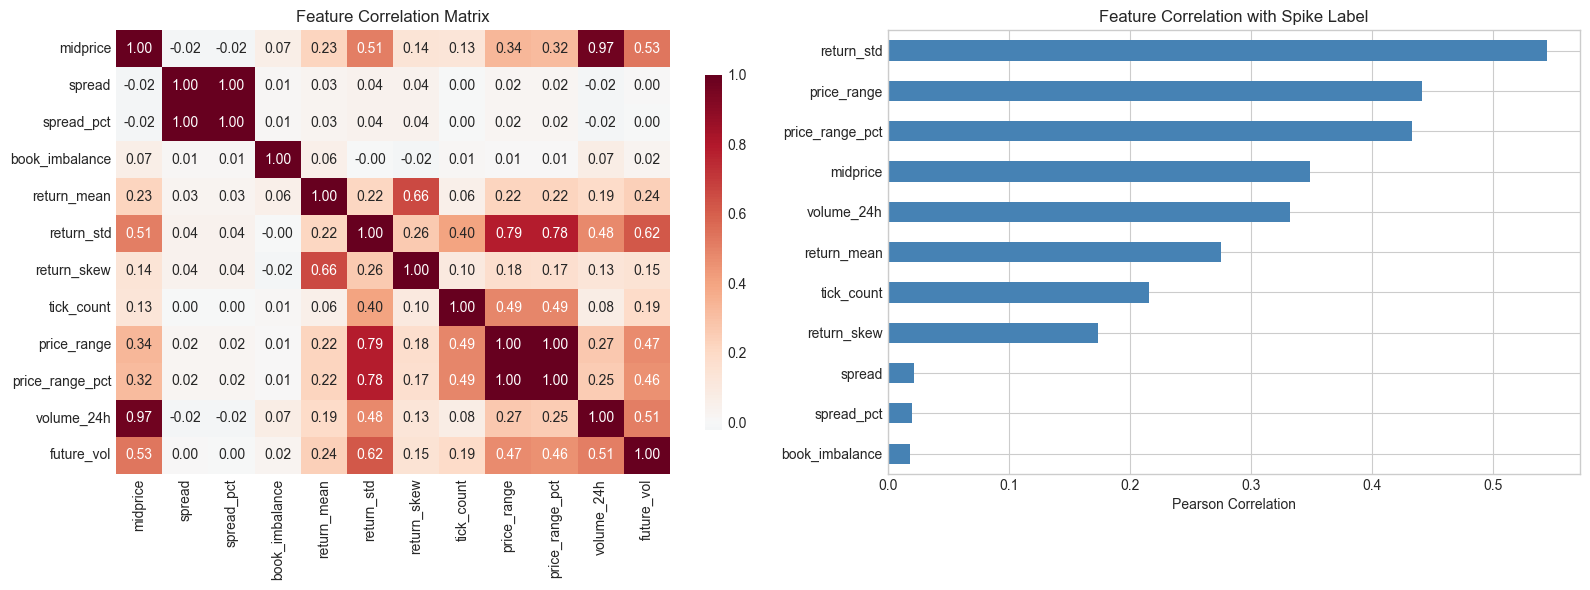


Correlation with spike label:
book_imbalance     0.0181
spread_pct         0.0201
spread             0.0217
return_skew        0.1741
tick_count         0.2162
return_mean        0.2754
volume_24h         0.3325
midprice           0.3491
price_range_pct    0.4335
price_range        0.4416
return_std         0.5450
dtype: float64


In [17]:
# Cell 4: Feature correlations
feature_cols = ["midprice", "spread", "spread_pct", "book_imbalance",
                "return_mean", "return_std", "return_skew", "tick_count",
                "price_range", "price_range_pct", "volume_24h"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
corr = df[feature_cols + ["future_vol"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Feature Correlation Matrix")

# Point-biserial: features vs spike label
spike_corr = df[feature_cols].corrwith(df["spike"]).sort_values()
spike_corr.plot(kind="barh", ax=axes[1], color=["crimson" if v < 0 else "steelblue" for v in spike_corr])
axes[1].set_title("Feature Correlation with Spike Label")
axes[1].set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.savefig("../reports/eda_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation with spike label:")
print(spike_corr.round(4))

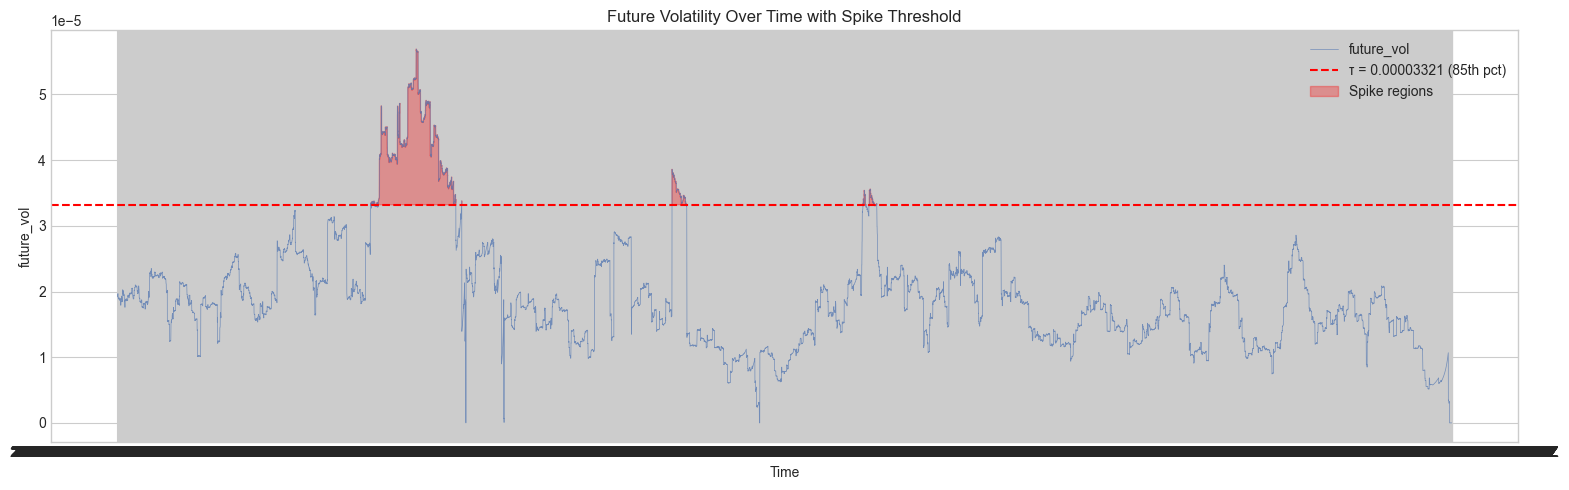

In [18]:
# Cell 5: Time series plot with threshold
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df["timestamp"], df["future_vol"], linewidth=0.5, alpha=0.7, label="future_vol")
ax.axhline(y=TAU, color="red", linestyle="--", linewidth=1.5, label=f"τ = {TAU:.8f} (85th pct)")
ax.fill_between(df["timestamp"], TAU, df["future_vol"],
                where=df["future_vol"] >= TAU, alpha=0.3, color="red", label="Spike regions")
ax.set_title("Future Volatility Over Time with Spike Threshold")
ax.set_xlabel("Time")
ax.set_ylabel("future_vol")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/eda_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

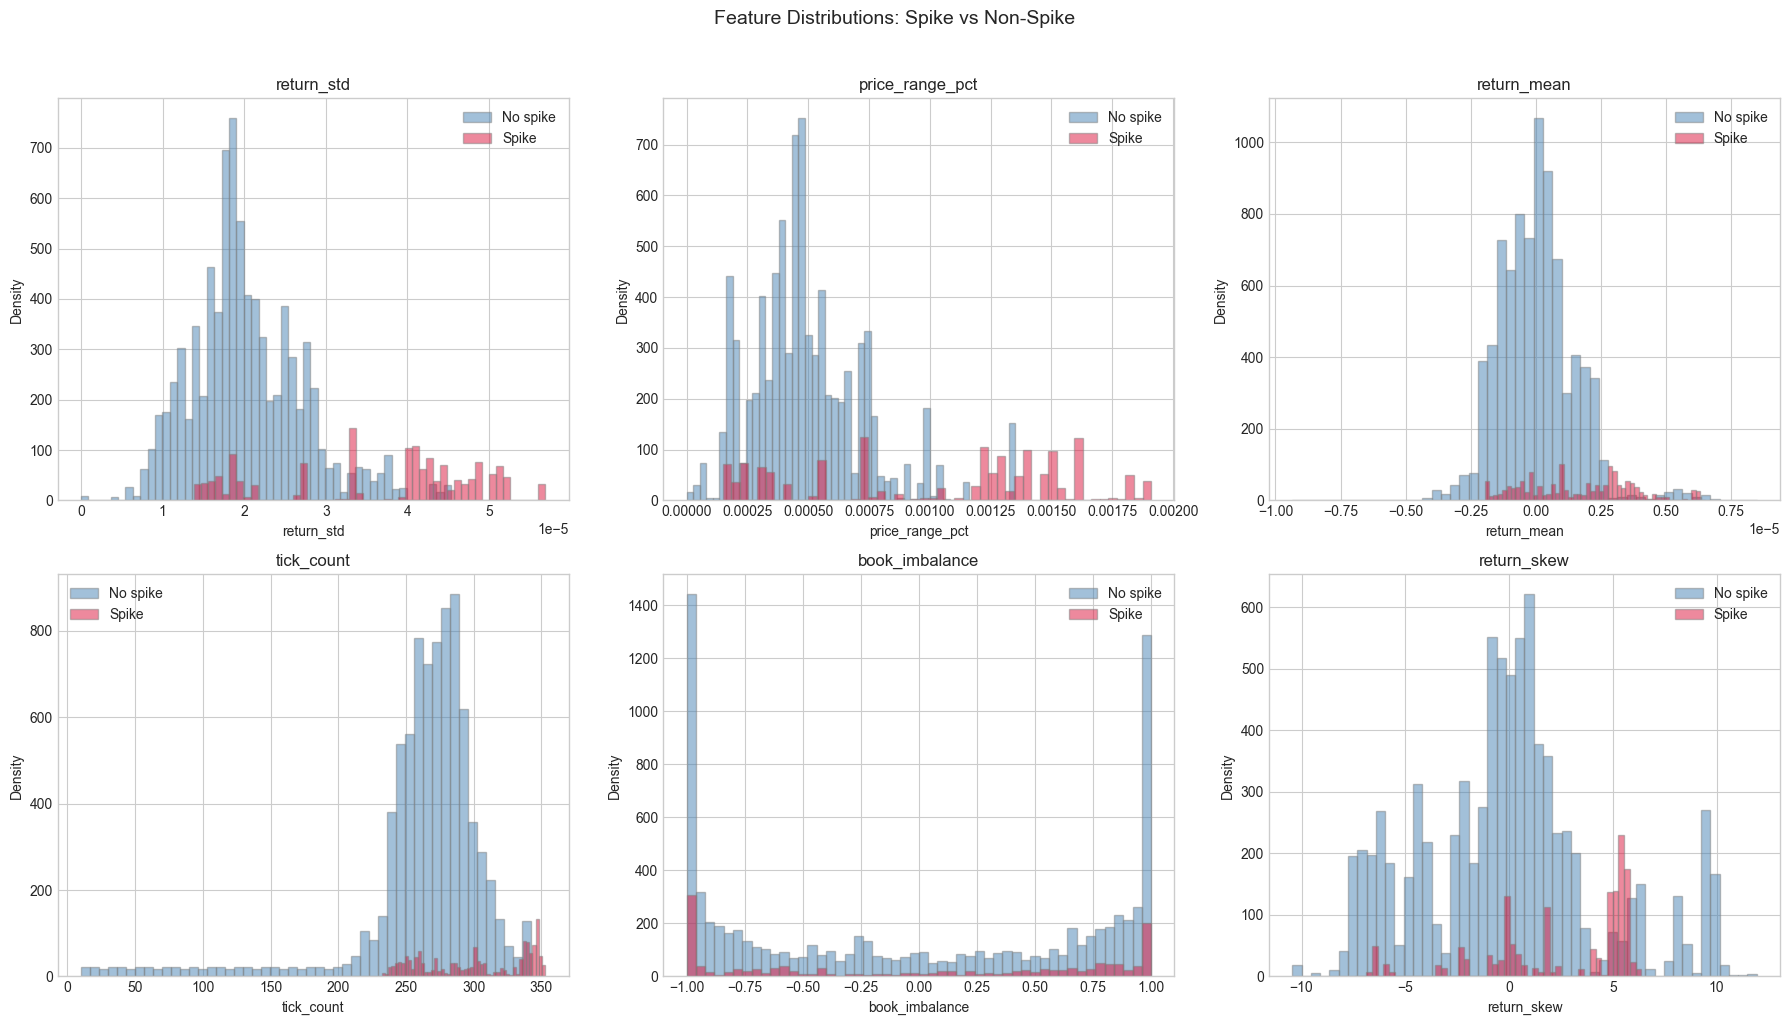

In [10]:
# ── Cell 5: Feature distributions by spike class ────────────────
# WHY: Correlation only tells us about LINEAR relationships between
# a feature and the spike label. But classifiers (especially tree-based
# ones like XGBoost) can exploit nonlinear patterns too.
#
# By plotting the distribution of each feature split by spike=0 vs
# spike=1, we can visually check:
#   - Do the distributions SEPARATE? (good — the feature is useful)
#   - Do they overlap completely? (bad — the feature adds no info)
#   - Is the relationship nonlinear? (e.g., spikes at BOTH extremes)
#
# This directly informs which features we keep for modeling and
# whether a linear model (LogReg) can capture the patterns or if
# we need a nonlinear model (XGBoost).

plot_features = ["return_std", "price_range_pct", "return_mean",
                 "tick_count", "book_imbalance", "return_skew"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    for label, color, name in [(0, "steelblue", "No spike"), (1, "crimson", "Spike")]:
        subset = df[df["spike"] == label][feat]
        axes[i].hist(subset, bins=50, alpha=0.5, color=color,
                     label=name, density=False, edgecolor="grey")
    axes[i].set_title(f"{feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("Feature Distributions: Spike vs Non-Spike", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

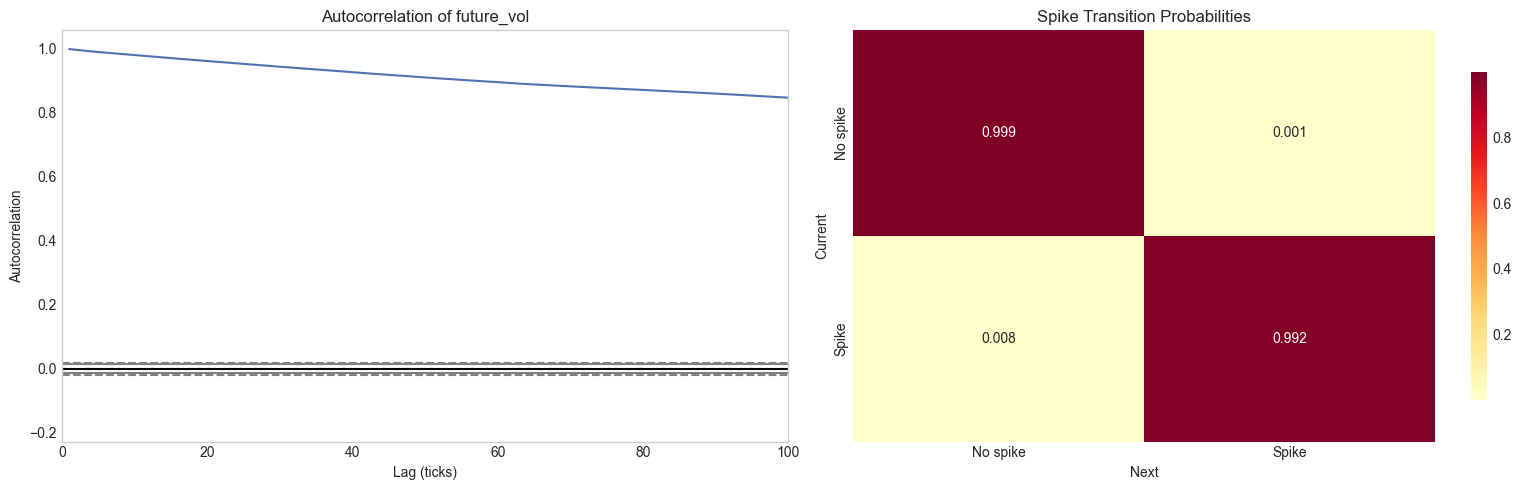

Transition matrix (row = current state, col = next state):
Next         0      1
Current              
0        0.999  0.001
1        0.008  0.992


In [19]:
# ── Cell 6: Volatility autocorrelation ──────────────────────────
# WHY: Financial volatility is known to "cluster" — periods of high
# volatility tend to be followed by more high volatility (this is
# called the ARCH effect in finance). If future_vol is autocorrelated,
# it means the most recent volatility reading (return_std) is itself
# a strong predictor of what comes next.
#
# We check this two ways:
# 1. Autocorrelation plot — shows correlation of future_vol with
#    its own lagged values. High bars at early lags = strong clustering.
# 2. Spike transition matrix — what fraction of spike windows are
#    followed by another spike? If spikes are "sticky," the model
#    can exploit momentum.
#
# This is important for the MODEL CARD: if autocorrelation is high,
# we should note that the model partly relies on volatility persistence,
# which could break down during regime changes.

from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Autocorrelation of future_vol (first 100 lags)
pd.plotting.autocorrelation_plot(df["future_vol"], ax=axes[0])
axes[0].set_xlim(0, 100)
axes[0].set_title("Autocorrelation of future_vol")
axes[0].set_xlabel("Lag (ticks)")

# Right: Spike transition probabilities
df["next_spike"] = df["spike"].shift(-1)
transitions = df.dropna(subset=["next_spike"])
transition_matrix = pd.crosstab(
    transitions["spike"], transitions["next_spike"].astype(int),
    rownames=["Current"], colnames=["Next"], normalize="index"
)

sns.heatmap(transition_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"shrink": 0.8},
            xticklabels=["No spike", "Spike"],
            yticklabels=["No spike", "Spike"])
axes[1].set_title("Spike Transition Probabilities")

plt.tight_layout()
plt.savefig("../reports/eda_autocorrelation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Transition matrix (row = current state, col = next state):")
print(transition_matrix.round(3))

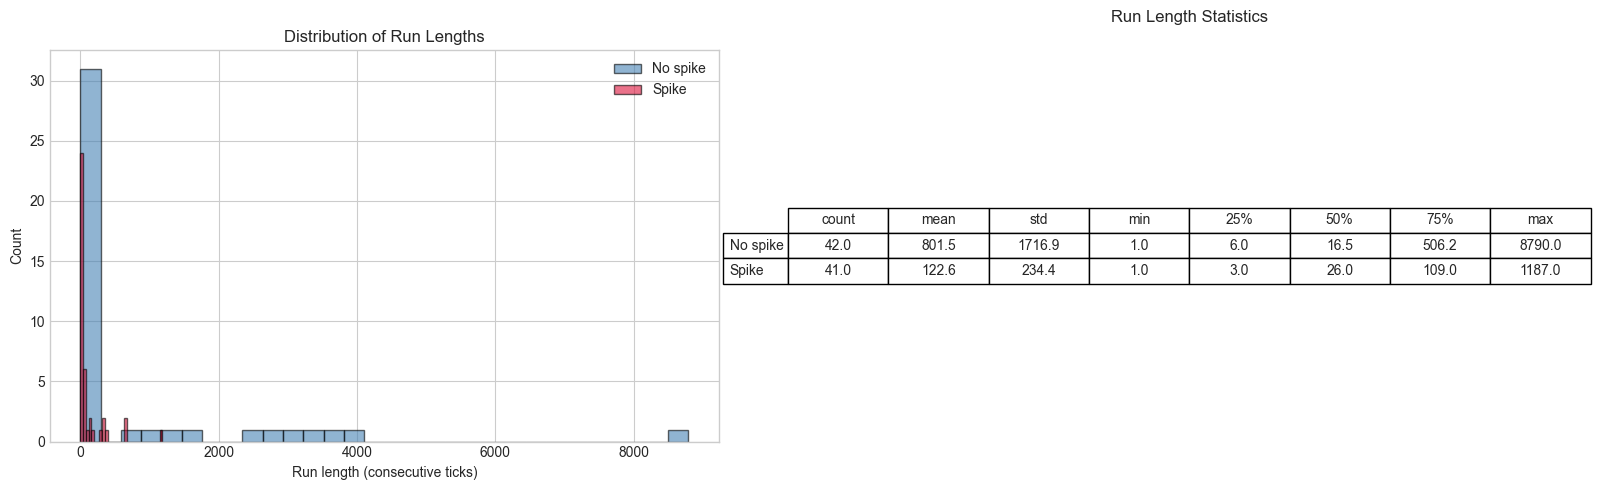


Total runs: 83
  Spike runs: 41
  No-spike runs: 42

Spike run lengths:
count      41.000000
mean      122.634146
std       234.363154
min         1.000000
25%         3.000000
50%        26.000000
75%       109.000000
max      1187.000000
Name: length, dtype: float64


In [27]:
# ── Cell 7: Spike run-length analysis ───────────────────────────
# WHY: The transition matrix told us spikes are "sticky," but HOW
# sticky? This cell measures the length of consecutive spike and
# non-spike runs (in number of ticks).
#
# This matters for two practical reasons:
# 1. BUSINESS VALUE: If spikes last for hundreds of ticks, a trader
#    has plenty of time to react even with a delayed alert. If they
#    last only 5-10 ticks, the model needs to fire early or it's
#    useless. This goes directly into the scoping brief / model card.
# 2. TRAIN/TEST INTEGRITY: If spikes come in a few long blocks,
#    a random train/test split will put adjacent (nearly identical)
#    ticks into both sets — inflating test metrics. We may need to
#    split by time or by spike-block to get honest evaluation.

# Compute run lengths
runs = []
current_val = df["spike"].iloc[0]
current_len = 1

for val in df["spike"].iloc[1:]:
    if val == current_val:
        current_len += 1
    else:
        runs.append({"state": "Spike" if current_val == 1 else "No spike",
                      "length": current_len})
        current_val = val
        current_len = 1
runs.append({"state": "Spike" if current_val == 1 else "No spike",
              "length": current_len})

runs_df = pd.DataFrame(runs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Run length distribution by state
for state, color in [("No spike", "steelblue"), ("Spike", "crimson")]:
    subset = runs_df[runs_df["state"] == state]["length"]
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=state, edgecolor="black")
axes[0].set_title("Distribution of Run Lengths")
axes[0].set_xlabel("Run length (consecutive ticks)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: Summary stats
summary = runs_df.groupby("state")["length"].describe()
axes[1].axis("off")
table = axes[1].table(
    cellText=summary.round(1).values,
    colLabels=summary.columns,
    rowLabels=summary.index,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[1].set_title("Run Length Statistics", pad=20)

plt.tight_layout()
plt.savefig("../reports/eda_run_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal runs: {len(runs_df)}")
print(f"  Spike runs: {len(runs_df[runs_df['state'] == 'Spike'])}")
print(f"  No-spike runs: {len(runs_df[runs_df['state'] == 'No spike'])}")
print(f"\nSpike run lengths:")
print(runs_df[runs_df["state"] == "Spike"]["length"].describe())